In [104]:
import os.path

import pandas as pd
from IPython.display import display
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pandas.core.common import random_state
from pygments.styles import trac
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge, Lasso
from sklearn.model_selection import GridSearchCV
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor

data_path = "train.csv"

if os.path.exists("../data/house_price_ds.csv"):
    data_path = "../data/house_price_ds.csv"

elif os.path.exists("data/house_price_ds.csv"):
    data_path = "data/house_price_ds.csv"

df = pd.read_csv(data_path)

display(df.head())
display(df.tail())
print("Dataset Shape:", df.shape)

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
1455,1456,60,RL,62.0,7917,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,8,2007,WD,Normal,175000
1456,1457,20,RL,85.0,13175,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,MnPrv,NaN,0,2,2010,WD,Normal,210000
1457,1458,70,RL,66.0,9042,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,GdPrv,Shed,2500,5,2010,WD,Normal,266500
1458,1459,20,RL,68.0,9717,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,142125
1459,1460,20,RL,75.0,9937,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,6,2008,WD,Normal,147500


Dataset Shape: (1460, 81)


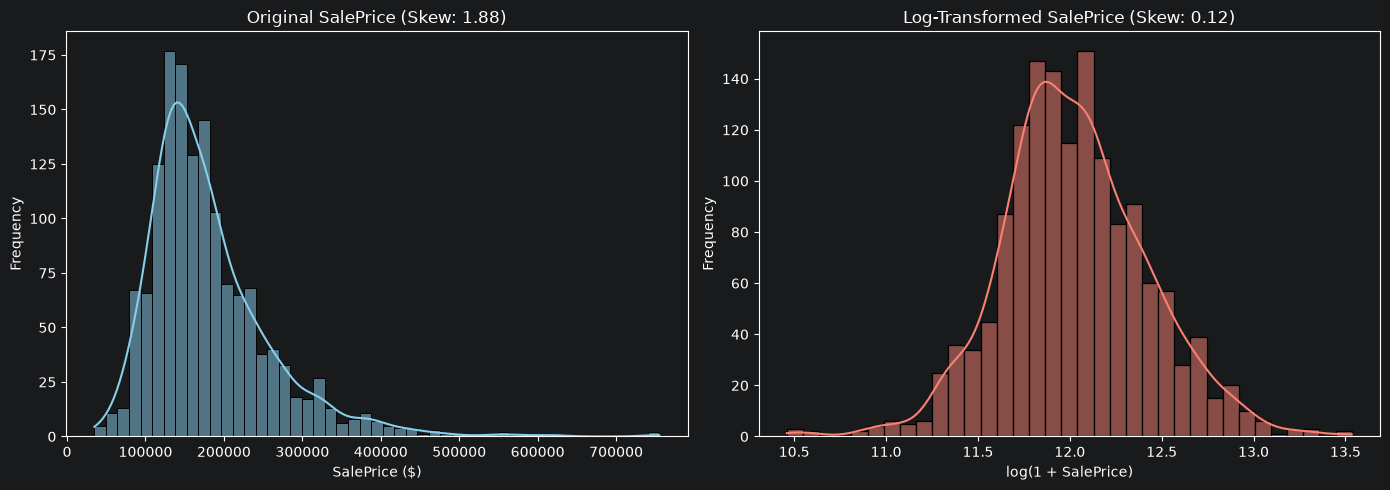

In [74]:
target = "SalePrice"

# Raw
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(14, 5))
sns.histplot(x=df[target], kde=True, ax=axes[0], color='skyblue')
axes[0].set_title(f"Original SalePrice (Skew: {df['SalePrice'].skew():.2f})")
axes[0].set_xlabel("SalePrice ($)")
axes[0].set_ylabel("Frequency")

# Log-Transformed
log_target = np.log1p(df[target])
sns.histplot(x=log_target, kde=True, ax=axes[1], color='salmon')
axes[1].set_title(f"Log-Transformed SalePrice (Skew: {log_target.skew():.2f})")
axes[1].set_xlabel("log(1 + SalePrice)")
axes[1].set_ylabel("Frequency")

plt.tight_layout()
plt.show()


**Question:**
*Explain why log-scaling is beneficial for linear regression models when target variables exhibit strong right-skewness.*
Log scaling is beneficial for linear regression models when target variables exhibit right-skewness when there is a hard limit on how small a value can be but not how large, significant skewnesss occurs, in this case 1.88. The reason skewness occurs in this example is houses realistically are not going to sell below a certain amount, in this dataset that is 35,000. Premium homes however can easily sell for 700,000 which causes the skewness.


In [75]:
# 1. Get raw counts of missing values > 0
missing_counts = df.isnull().sum()[df.isnull().sum() > 0]

# 2. Calculate percentage based on total rows
missing_percent = (missing_counts / len(df)) * 100

# 3. Create a clean DataFrame
missing_df = pd.DataFrame({
    'Missing Count': missing_counts,
    'Missing Percent (%)': missing_percent.round(2)
})

# 4. Sort descending (most missing to least missing)
missing_df = missing_df.sort_values(by='Missing Count', ascending=False)

# Display the resulting table
display(missing_df)

,Missing Count,Missing Percent (%)
PoolQC,1453,99.52
MiscFeature,1406,96.30
Alley,1369,93.77
Fence,1179,80.75
MasVnrType,872,59.73
FireplaceQu,690,47.26
LotFrontage,259,17.74
GarageType,81,5.55
GarageYrBlt,81,5.55
GarageFinish,81,5.55


10 most correlated features:


SalePrice       1.000000
OverallQual     0.790982
GrLivArea       0.708624
GarageCars      0.640409
GarageArea      0.623431
TotalBsmtSF     0.613581
1stFlrSF        0.605852
FullBath        0.560664
TotRmsAbvGrd    0.533723
YearBuilt       0.522897
YearRemodAdd    0.507101
Name: SalePrice, dtype: float64

<Axes: >

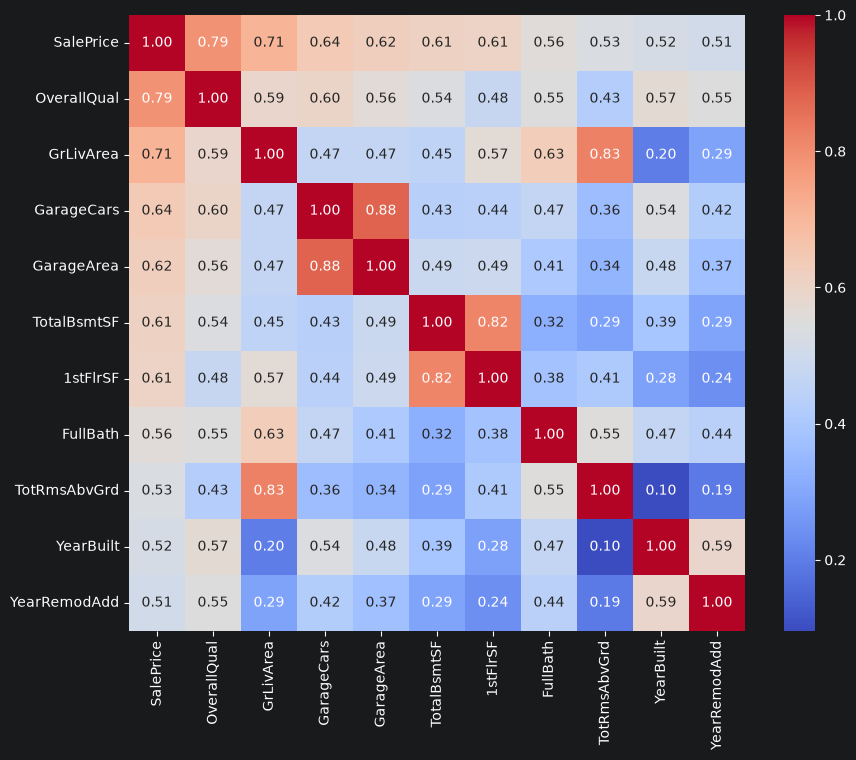

In [76]:
num_df = df.select_dtypes(include=[np.number])
corr_matrix = num_df.corr()
sale_price_corr = corr_matrix[target]

print("10 most correlated features:")
sorted_target_corr = sale_price_corr.sort_values(ascending=False).head(11)
display(sorted_target_corr)

top_correlated_columns = sorted_target_corr.index

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix.loc[top_correlated_columns,top_correlated_columns], annot=True, fmt='.2f', cmap='coolwarm', square=True)

<Axes: xlabel='GrLivArea', ylabel='SalePrice'>

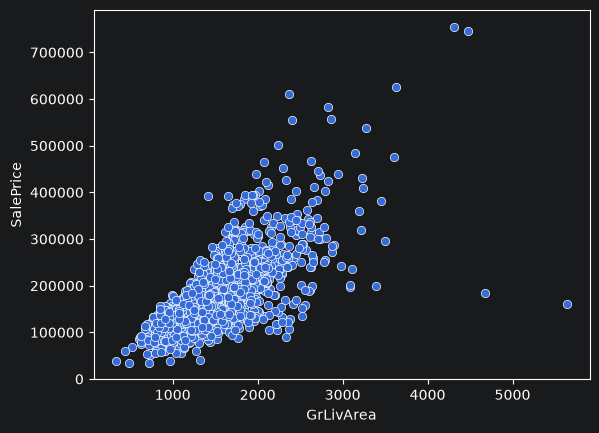

In [81]:
sns.scatterplot(df, x="GrLivArea", y="SalePrice")

In [94]:
X = df.drop(columns=["Id",target])
y = np.log1p(df[target])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

Xnumerical_cols = X.select_dtypes(include=[np.number]).columns.tolist()
Xcategorical_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (1168, 79)
X_test shape: (292, 79)
y_train shape: (1168,)
y_test shape: (292,)


C:\Users\Carter\AppData\Local\Temp\ipykernel_40824\4178706273.py:7: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  Xcategorical_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()


In [98]:
num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

cat_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', num_pipeline, Xnumerical_cols),
        ('cat', cat_pipeline, Xcategorical_cols)
    ]
)

X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print("X_train shape:", X_train_processed.shape)
print("X_test shape:", X_test_processed.shape)

X_train shape: (1168, 285)
X_test shape: (292, 285)


In [101]:
lr_model = LinearRegression()
lr_model.fit(X_train_processed, y_train)

param_grid = {'alpha': [0.1, 1.0, 10.0, 100.0, 500.0]}
ridge_cv = GridSearchCV(estimator=Ridge(random_state=42), param_grid=param_grid, cv=5, scoring='neg_mean_squared_error')
ridge_cv.fit(X_train_processed, y_train)
print("Best Param RidgeCV: ", ridge_cv.best_params_)
print("Best Score RidgeCV: ", ridge_cv.best_score_)

Best Param GSCV:  {'alpha': 10.0}
Best Score GSCV:  -0.022089414292180396


In [105]:
knn_param_grid = {
    'n_neighbors': [3, 5, 7, 9, 11, 15, 21],
    'weights': ['uniform', 'distance']
}

knn_cv = GridSearchCV(estimator=KNeighborsRegressor(), param_grid=knn_param_grid, cv=5, scoring='neg_mean_squared_error')
knn_cv.fit(X_train_processed, y_train)

tree_param_grid = {
    'max_depth': [3, 5, 10, 15, None],
    'min_samples_split': [2, 5, 10, 20]
}

tree_cv = GridSearchCV(estimator=DecisionTreeRegressor(random_state=42), param_grid=tree_param_grid, cv=5, scoring='neg_mean_squared_error')
tree_cv.fit(X_train_processed, y_train)

print("Best Param KNN CV: ", knn_cv.best_params_)
print("Best Score KNN CV: ", knn_cv.best_score_)
print("Best Param Tree CV: ", tree_cv.best_params_)
print("Best Score Tree CV: ", tree_cv.best_score_)


Best Param KNN CV:  {'n_neighbors': 9, 'weights': 'distance'}
Best Score KNN CV:  -0.028934694681995228
Best Param Tree CV:  {'max_depth': 15, 'min_samples_split': 20}
Best Score Tree CV:  -0.03863872165294976
